# 55只等权组合超额收益分析

## 核心问题
1. 这55只科技股的等权组合在什么市场环境下有超额收益？
2. 超额收益的来源有何特征（历史描述统计）？

## 定性前提
这55只**不是市值龙头**（仅15%是申万一级行业市值TOP3，21只甚至不在CSI300/500成分中）。

## 研究框架
- Part 1: 基础画像（行业/市值/逐年覆盖率）
- Part 2: 等权组合超额收益（双基准 + 中位数 + IQR去极值）
- Part 3: 超额收益条件分组统计（风格 × 波动率 × 市场方向，仅描述统计）
- Part 4: 申万行业层面超额对比
- Part 5: 当前市场状态（描述统计，非预测）
- Part 6: 研究局限 & 注意事项

## 数据与方法
所有方法有前例可循：Q1/Q3/Q4/Q5/Q6 方法复用，详见各cell注释。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings, os, re, glob as _glob
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA = Path('research_cache')
CACHE55 = Path('research_cache/55stock')
CACHE55.mkdir(parents=True, exist_ok=True)
print('Ready')

Ready


## Part 1: 基础画像

In [2]:
# 加载55只股票(无header行)
df55 = pd.read_csv('55个股票.md', sep='\t', header=None)
df55.columns = ['code','name']
df55['code'] = df55['code'].astype(str).str.zfill(6)
print(f'Total: {len(df55)} stocks')

# 申万一级行业分类
# 34只在CSI300/500成分中，从xlsx col14读取（同Q5/Q6）
xlsx_files = _glob.glob('成分详情*.xlsx')
df_xlsx = pd.concat([pd.read_excel(f) for f in xlsx_files], ignore_index=True)
df_xlsx['code'] = df_xlsx.iloc[:,1].astype(str).str.replace('.SZ','').str.replace('.SH','').str.zfill(6)
df_xlsx['sw'] = df_xlsx.iloc[:,14]

# 21只不在成分中，从stock_profile_cninfo获取CSRC行业后手工映射为申万一级
# | warning: CSRC→SW为手工映射，标签可能有偏差
CSRC_MAP = {
    '688521': '计算机', '601126': '电力设备', '603667': '机械设备', '002896': '机械设备',
    '688146': '国防军工', '688630': '机械设备', '001309': '电子', '300913': '电力设备',
    '603256': '建筑材料', '301217': '电子', '301511': '电子', '601208': '基础化工',
    '002364': '电力设备', '300870': '电子', '002536': '汽车', '601869': '电子',
    '603629': '钢铁', '603601': '建筑材料', '002484': '电子', '000636': '电子',
    '688313': '电子',
}

df55 = df55.merge(df_xlsx[['code','sw']].drop_duplicates(subset=['code']), on='code', how='left')
df55['sw'] = df55['sw'].fillna(df55['code'].map(CSRC_MAP)).fillna('其他')

print(f'\n申万一级行业分布:')
for ind, cnt in df55.groupby('sw').size().sort_values(ascending=False).items():
    print(f'  {ind}: {cnt}只')
df55.head(10)

Total: 55 stocks

申万一级行业分布:
  电子: 23只
  电力设备: 9只
  机械设备: 7只
  通信: 5只
  建筑材料: 3只
  国防军工: 2只
  计算机: 2只
  基础化工: 1只
  家用电器: 1只
  汽车: 1只
  钢铁: 1只


,code,name,sw
0,688521,芯原股份,计算机
1,300750,宁德时代,电力设备
2,002202,金风科技,电力设备
3,300274,阳光电源,电力设备
4,605117,德业股份,电力设备
5,601126,四方股份,电力设备
6,600089,特变电工,电力设备
7,002050,三花智控,家用电器
8,603667,五洲新春,机械设备
9,002896,中大力德,机械设备


### 申万行业分布

In [3]:
sw_stat = df55.groupby('sw').agg(n=('code','size')).sort_values('n', ascending=False)
print(sw_stat.to_string())

       n
sw      
电子    23
电力设备   9
机械设备   7
通信     5
建筑材料   3
国防军工   2
计算机    2
基础化工   1
家用电器   1
汽车     1
钢铁     1


### 市值分布 & CSI300/500定位

In [4]:
# Load CSI300+500 for market cap reference
xlsx_files = _glob.glob('成分详情*.xlsx')
csi300 = pd.read_excel([f for f in xlsx_files if '000300' in f][0])
csi500 = pd.read_excel([f for f in xlsx_files if '000905' in f][0])
cols_use = {1: 'code', 2: 'name', 11: 'total_mv', 14: 'industry'}
csi300 = csi300.iloc[:, list(cols_use.keys())].copy()
csi300.columns = list(cols_use.values())
csi500 = csi500.iloc[:, list(cols_use.keys())].copy()
csi500.columns = list(cols_use.values())
df_all = pd.concat([csi300, csi500], ignore_index=True)
df_all['code'] = df_all['code'].astype(str).str.replace('.SZ','').str.replace('.SH','').str.zfill(6)
df_all = df_all.drop_duplicates(subset=['code'])
df_all['total_mv'] = pd.to_numeric(df_all['total_mv'], errors='coerce')
df_all = df_all[df_all['total_mv'] > 0]

# How many of the 55 are in CSI300/500?
all_codes = set(df_all['code'])
in_index = df55['code'].isin(all_codes)
print(f'在CSI300/500成分中: {in_index.sum()}/{len(df55)}')
print(f'不在CSI300/500成分中: {(~in_index).sum()}/{len(df55)}')

# Match market cap
df55_m = df55.merge(df_all[['code','total_mv','industry']], on='code', how='left')
print(f'\n市值统计 (有数据的{df55_m["total_mv"].notna().sum()}只):')
mv = df55_m['total_mv'].dropna()
print(f'  P25={mv.quantile(0.25):.0f}亿  P50={mv.median():.0f}亿  P75={mv.quantile(0.75):.0f}亿')
print(f'  最小={mv.min():.0f}亿  最大={mv.max():.0f}亿')
print(f'\n  参考: CSI300中位数={df_all[df_all["code"].isin(csi300["code"].str.replace(".SZ","").str.replace(".SH","").str.zfill(6))]["total_mv"].median():.0f}亿')
print(f'          CSI500中位数={df_all[df_all["code"].isin(csi500["code"].str.replace(".SZ","").str.replace(".SH","").str.zfill(6))]["total_mv"].median():.0f}亿')

# Leader pool: TOP3 per industry
leaders = []
for ind, grp in df_all.groupby('industry'):
    grp_sorted = grp.sort_values('total_mv', ascending=False)
    for rank, (_, row) in enumerate(grp_sorted.head(3).iterrows()):
        leaders.append({'industry': ind, 'rank': rank+1, 'code': row['code']})
df_leader = pd.DataFrame(leaders)
in_leader = df55['code'].isin(df_leader['code'])
print(f'\n在行业市值TOP3中: {in_leader.sum()}/{len(df55)} ({100*in_leader.sum()/len(df55):.0f}%)')

在CSI300/500成分中: 34/55
不在CSI300/500成分中: 21/55

市值统计 (有数据的34只):
  P25=1173亿  P50=2027亿  P75=3808亿
  最小=540亿  最大=17974亿

  参考: CSI300中位数=1058亿
          CSI500中位数=285亿

在行业市值TOP3中: 8/55 (15%)


### 逐年数据覆盖率

In [5]:
def load_daily(code):
    files = sorted(DATA.glob(f'stock_tx_{code}_*.csv'))
    if not files: return None
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f, index_col=0, parse_dates=True)
            if 'close' in df.columns and len(df) > 10:
                dfs.append(df[['close']])
        except: continue
    if not dfs: return None
    df_all = pd.concat(dfs).sort_index()
    df_all = df_all[~df_all.index.duplicated(keep='last')]
    return df_all

# Count coverage per year
first_dates = {}
for _, row in df55.iterrows():
    code = row['code']
    d = load_daily(code)
    if d is None: continue
    first_dates[code] = d.index[0]

print(f'有日K数据: {len(first_dates)}/55')
print()
print('逐年可用股票数:')
for yr in range(2020, 2027):
    count = sum(1 for c in first_dates if first_dates[c].year <= yr)
    ipos = sum(1 for c in first_dates if first_dates[c].year == yr)
    ipo_str = f' (+{ipos}只新上市)' if ipos > 0 else ''
    print(f'  {yr}: {count}/55{ipo_str}')

# Show the 2 stocks that lack 2022
print('\n2022年仍缺失的2只(因IPO时间):')
for code, d in first_dates.items():
    if d.year > 2022:
        row = df55[df55['code']==code].iloc[0]
        print(f'  {code} {row["name"]}: 首次数据 {d.date()}')

有日K数据: 55/55

逐年可用股票数:
  2020: 30/55 (+30只新上市)
  2021: 31/55 (+1只新上市)
  2022: 53/55 (+22只新上市)
  2023: 55/55 (+2只新上市)
  2024: 55/55
  2025: 55/55
  2026: 55/55

2022年仍缺失的2只(因IPO时间):
  688146 中船特气: 首次数据 2023-04-21
  301511 德福科技: 首次数据 2023-08-17


## Part 2: 等权超额收益

**等权组合**: 每月所有可用股票收益的横截面均值（同Q3 step4C行业等权逻辑），覆盖率阈值≥30%或≥10只。

**双基准**: CSI1000 (同类市值层) 和 CSI300 (大盘基准)，同时对比。

**去极值**: 标准IQR规则（Q1−1.5×IQR ~ Q3+1.5×IQR），不是固定N。

In [6]:
# Build monthly returns for each stock
stock_monthly = {}
for _, row in df55.iterrows():
    code = row['code']
    d = load_daily(code)
    if d is None: continue
    m = d.resample('ME').last().pct_change().dropna()
    if len(m) > 3:
        stock_monthly[code] = m

# Equal-weight portfolio
all_dates = sorted(set(d for m in stock_monthly.values() for d in m.index))
portfolio_ret = []
for dt in all_dates:
    vals = [m.loc[dt].iloc[0] for m in stock_monthly.values()
            if dt in m.index and np.isfinite(m.loc[dt].iloc[0])]
    if len(vals) >= max(10, len(stock_monthly)*0.3):
        portfolio_ret.append({'date': dt, 'ret': np.mean(vals), 'n': len(vals)})

df_port = pd.DataFrame(portfolio_ret).set_index('date')
print(f'Portfolio: {len(df_port)} months, {df_port.index[0].date()} ~ {df_port.index[-1].date()}')
print(f'Avg constituents per month: {df_port["n"].mean():.0f}')

Portfolio: 76 months, 2020-02-29 ~ 2026-05-31
Avg constituents per month: 42



=== 55只等权组合 vs CSI1000 ===
  月数: 76
  均值: +2.51%/月
  中位数: +2.11%/月
  胜率: 63%
  累计: 487.1%
  年化: 32.2%
  去极值(IQR×1.5, 移除4个月):
    均值: +1.63%/月
    累计: 198.6%

  最大超额月 (top 5):
    2025-08-31: +22% (组合+33%, CSI1000+12%)
    2026-04-30: +22% (组合+32%, CSI1000+10%)
    2025-09-30: +17% (组合+19%, CSI1000+2%)
    2023-03-31: +14% (组合+13%, CSI1000-1%)
    2025-12-31: +13% (组合+16%, CSI1000+4%)
  最大回撤月 (bottom 5):
    2020-05-31: -8% (组合-6%, CSI1000+2%)
    2021-08-31: -8% (组合-2%, CSI1000+6%)
    2023-07-31: -6% (组合-7%, CSI1000-1%)
    2021-03-31: -6% (组合-7%, CSI1000-1%)
    2020-03-31: -6% (组合-14%, CSI1000-8%)

=== 55只等权组合 vs CSI300 ===
  月数: 76
  均值: +2.92%/月
  中位数: +0.91%/月
  胜率: 61%
  累计: 634.5%
  年化: 37.0%
  去极值(IQR×1.5, 移除1个月):
    均值: +2.64%/月
    累计: 494.4%

  最大超额月 (top 5):
    2026-04-30: +24% (组合+32%, CSI300+8%)
    2025-08-31: +23% (组合+33%, CSI300+10%)
    2021-07-31: +17% (组合+9%, CSI300-8%)
    2025-09-30: +15% (组合+19%, CSI300+3%)
    2025-12-31: +14% (组合+16%, CSI300+2%)
  最大回撤月 (bo

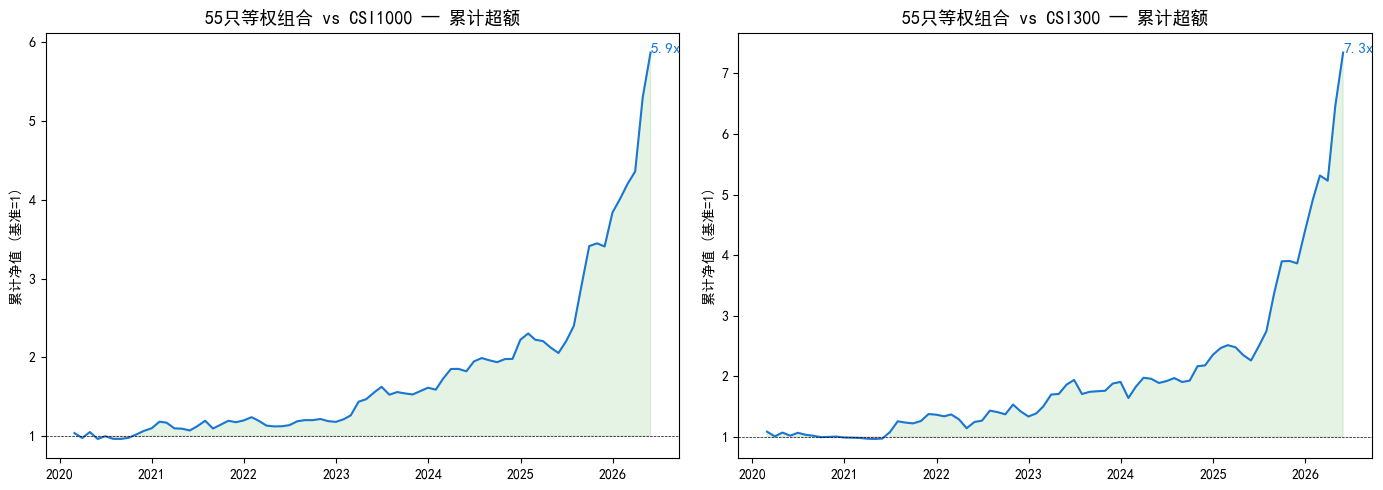

图已保存: 55stock_cumulative_excess.png


In [7]:
# Load benchmarks
csi1k = pd.read_csv(DATA/'CSI1000_price.csv', index_col=0, parse_dates=True)
csi300 = pd.read_csv(DATA/'CSI300_price.csv', index_col=0, parse_dates=True)
csi1k_m = csi1k['close'].resample('ME').last().pct_change().dropna()
csi300_m = csi300['close'].resample('ME').last().pct_change().dropna()

common = df_port.index.intersection(csi1k_m.index).intersection(csi300_m.index)
excess_1k = pd.Series([df_port.loc[dt,'ret'] - csi1k_m.loc[dt] for dt in common], index=common)
excess_300 = pd.Series([df_port.loc[dt,'ret'] - csi300_m.loc[dt] for dt in common], index=common)

def describe(name, ex, bench_m):
    top5 = ex.nlargest(5); bot5 = ex.nsmallest(5)
    # 标准IQR去极值 (Q1−1.5×IQR ~ Q3+1.5×IQR)，不是固定N
    Q1_val = ex.quantile(0.25); Q3_val = ex.quantile(0.75)
    IQR = Q3_val - Q1_val
    ex_clean = ex[(ex >= Q1_val - 1.5*IQR) & (ex <= Q3_val + 1.5*IQR)]
    print(f'\n=== 55只等权组合 vs {name} ===')
    print(f'  月数: {len(ex)}')
    print(f'  均值: {ex.mean()*100:+.2f}%/月')
    print(f'  中位数: {ex.median()*100:+.2f}%/月')
    print(f'  胜率: {(ex>0).mean()*100:.0f}%')
    print(f'  累计: {((1+ex).prod()-1)*100:.1f}%')
    print(f'  年化: {((1+ex).prod()**(12/len(ex))-1)*100:.1f}%')
    print(f'  去极值(IQR×1.5, 移除{len(ex)-len(ex_clean)}个月):')
    print(f'    均值: {ex_clean.mean()*100:+.2f}%/月')
    print(f'    累计: {((1+ex_clean).prod()-1)*100:.1f}%')
    print(f'\n  最大超额月 (top 5):')
    for d, v in top5.items():
        print(f'    {d.date()}: {v*100:+.0f}% (组合{df_port.loc[d,"ret"]*100:+.0f}%, {name}{bench_m.loc[d]*100:+.0f}%)')
    print(f'  最大回撤月 (bottom 5):')
    for d, v in bot5.items():
        print(f'    {d.date()}: {v*100:+.0f}% (组合{df_port.loc[d,"ret"]*100:+.0f}%, {name}{bench_m.loc[d]*100:+.0f}%)')

describe('CSI1000', excess_1k, csi1k_m)
describe('CSI300', excess_300, csi300_m)

# Chart: cumulative excess
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ex, label in [(axes[0], excess_1k, 'CSI1000'), (axes[1], excess_300, 'CSI300')]:
    cum = (1 + ex).cumprod()
    ax.plot(cum.index, cum, color='#1976D2', linewidth=1.5)
    ax.axhline(y=1, color='black', linewidth=0.5, linestyle='--')
    ax.fill_between(cum.index, 1, cum, where=cum>1, color='#4CAF50', alpha=0.15)
    ax.fill_between(cum.index, 1, cum, where=cum<=1, color='#F44336', alpha=0.15)
    ax.set_title(f'55只等权组合 vs {label} — 累计超额', fontsize=13)
    ax.set_ylabel('累计净值 (基准=1)')
    cum_final = cum.iloc[-1]
    ax.annotate(f'{cum_final:.1f}x', xy=(cum.index[-1], cum_final),
                fontsize=11, fontweight='bold', color='#1976D2')
plt.tight_layout()
plt.savefig('55stock_cumulative_excess.png', dpi=120, bbox_inches='tight')
plt.show()
print('图已保存: 55stock_cumulative_excess.png')

## Part 3: 等权超额收益条件分组统计

**方法**: 月末计算市场状态——风格(CSI1000/CSI300比值的12月MA方向,同Q1 1D)、波动率(CSI300 60d年化,同Q1/Q4)、市场方向(CSI300月收益)——然后分组统计等权组合在各环境下的超额。

**注意事项**:
- 风格用12月MA上升/下降分类（同Q1 1D方法论），不是随手阈值
- 波动率用中位数二分（标准做法）
- n<6的格标注样本量不足
- 以下仅为描述统计，不是预测量

等权超额收益 = f(风格, 波动率):
环境                             n       均值      中位数      胜率     备注
-----------------------------------------------------------------
小盘偏强   x 低波                 28    +3.8%    +3.5%     68%  
小盘偏强   x 高波                 24    +0.9%    +0.6%     54%  
大盘偏强   x 低波                 10    +1.8%    +2.2%     70%  
大盘偏强   x 高波                 14    +3.2%    +2.8%     64%  

等权超额收益 = f(风格, 市场方向):
  小盘偏强   x 上涨  : n=27, mean=+4.4%/m, win=70%
  小盘偏强   x 下跌  : n=25, mean=+0.4%/m, win=52%
  大盘偏强   x 上涨  : n=11, mean=+3.9%/m, win=73%
  大盘偏强   x 下跌  : n=13, mean=+1.5%/m, win=62%


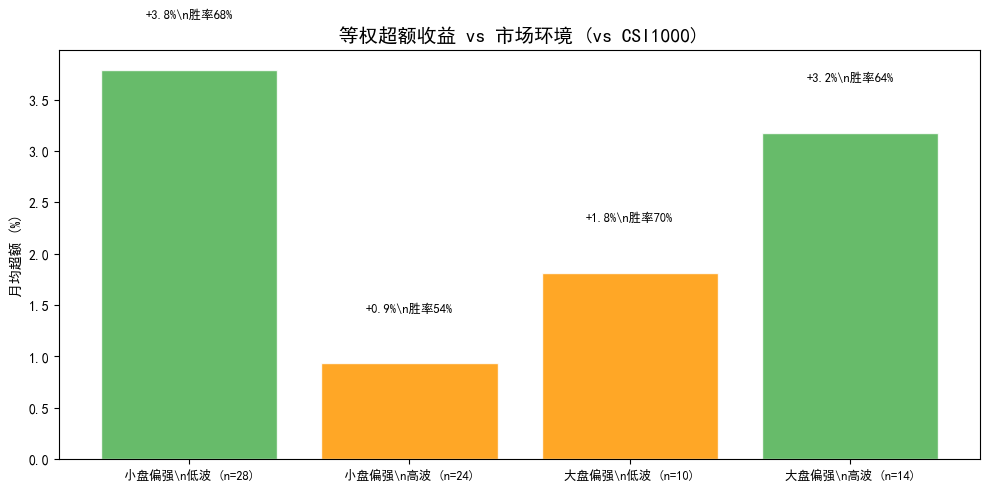

In [8]:
# Build condition matrix
# 风格方向: 12月MA上升=小盘偏强, 12月MA下降=大盘偏强 (同Q1 1D)
ratio = csi1k['close'] / csi300['close']
ratio_ma12 = ratio.rolling(252, min_periods=126).mean()
ratio_ma12_m = ratio_ma12.resample('ME').last().dropna()
ma_direction = ratio_ma12_m.diff()  # 正值=MA向上=小盘偏强

csi300_vol = csi300['close'].pct_change().rolling(60).std() * np.sqrt(252)
vol_m = csi300_vol.resample('ME').last()

df_cond = pd.DataFrame({
    'excess_1k': excess_1k.values,
    'excess_300': excess_300.values,
    'csi300_ret': csi300_m.reindex(common).values
}, index=common)

df_cond['style'] = '中性'
df_cond.loc[df_cond.index.isin(ma_direction[ma_direction > 0].index), 'style'] = '小盘偏强'
df_cond.loc[df_cond.index.isin(ma_direction[ma_direction < 0].index), 'style'] = '大盘偏强'
df_cond['vol'] = '低波'
vol_median = vol_m.reindex(common).median()
df_cond.loc[vol_m.reindex(common) > vol_median, 'vol'] = '高波'
df_cond['mkt_dir'] = '上涨'
df_cond.loc[df_cond['csi300_ret'] < 0, 'mkt_dir'] = '下跌'

# Primary table: Style x Vol
print('等权超额收益 = f(风格, 波动率):')
print(f'{"环境":<28s} {"n":>3s}  {"均值":>7s}  {"中位数":>7s}  {"胜率":>6s}  {"备注":>5s}')
print('-' * 65)
for s in ['小盘偏强','大盘偏强','中性']:
    for v in ['低波','高波']:
        sub = df_cond[(df_cond['style']==s) & (df_cond['vol']==v)]
        if len(sub) > 0:
            m = sub['excess_1k'].mean() * 100
            med = sub['excess_1k'].median() * 100
            w = (sub['excess_1k'] > 0).mean() * 100
            note = '<<< 样本不足' if len(sub) < 6 else ''
            print(f'{s:6s} x {v:4s}              {len(sub):3d}  {m:+6.1f}%  {med:+6.1f}%  {w:5.0f}%  {note}')

# Style x Market direction
print(f'\n等权超额收益 = f(风格, 市场方向):')
for s in ['小盘偏强','大盘偏强']:
    for d in ['上涨','下跌']:
        sub = df_cond[(df_cond['style']==s) & (df_cond['mkt_dir']==d)]
        if len(sub) > 0:
            m = sub['excess_1k'].mean() * 100
            w = (sub['excess_1k'] > 0).mean() * 100
            print(f'  {s:6s} x {d:4s}: n={len(sub):2d}, mean={m:+.1f}%/m, win={w:.0f}%')

# Chart: bar chart of Style x Vol
fig, ax = plt.subplots(figsize=(10, 5))
categories = []; means = []; wins = []; colors = []
for s in ['小盘偏强','大盘偏强']:
    for v in ['低波','高波']:
        sub = df_cond[(df_cond['style']==s) & (df_cond['vol']==v)]
        if len(sub) > 0:
            categories.append(f'{s}\\n{v} (n={len(sub)})')
            m = sub['excess_1k'].mean() * 100
            means.append(m)
            wins.append((sub['excess_1k'] > 0).mean() * 100)
            colors.append('#4CAF50' if m > 2 else ('#FF9800' if m > 0 else '#F44336'))

x = range(len(categories))
bars = ax.bar(x, means, color=colors, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=9)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('月均超额 (%)')
ax.set_title('等权超额收益 vs 市场环境 (vs CSI1000)', fontsize=14)
for i, (m, w) in enumerate(zip(means, wins)):
    ax.text(i, m + (0.5 if m >= 0 else -1.5), f'{m:+.1f}%\\n胜率{w:.0f}%',
            ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('55stock_condition_bar.png', dpi=120, bbox_inches='tight')
plt.show()

## Part 4: 申万行业层面等权超额收益

按11个申万一级行业分别构建等权子组合，计算各行业 vs CSI1000的超额。

申万行业  n股票  n月    月均   中位数   胜率    累计
  钢铁    1  52  5.69 -0.72 48.0 617.4
  通信    5  76  3.51  2.39 61.0 859.3
机械设备    7  76  3.23  0.98 54.0 709.5
电力设备    9  76  2.86  1.21 63.0 585.6
  电子   23  70  2.59  1.11 61.0 400.7
  汽车    1  35  2.48 -1.23 46.0  98.7
家用电器    1  76  1.55 -1.21 46.0  83.3
国防军工    2  76  1.24 -1.31 41.0  39.5
 计算机    2  76  0.60 -1.22 43.0  13.5
建筑材料    3  35 -0.70 -1.70 43.0 -25.5
基础化工    1  35 -1.29 -2.42 37.0 -42.3


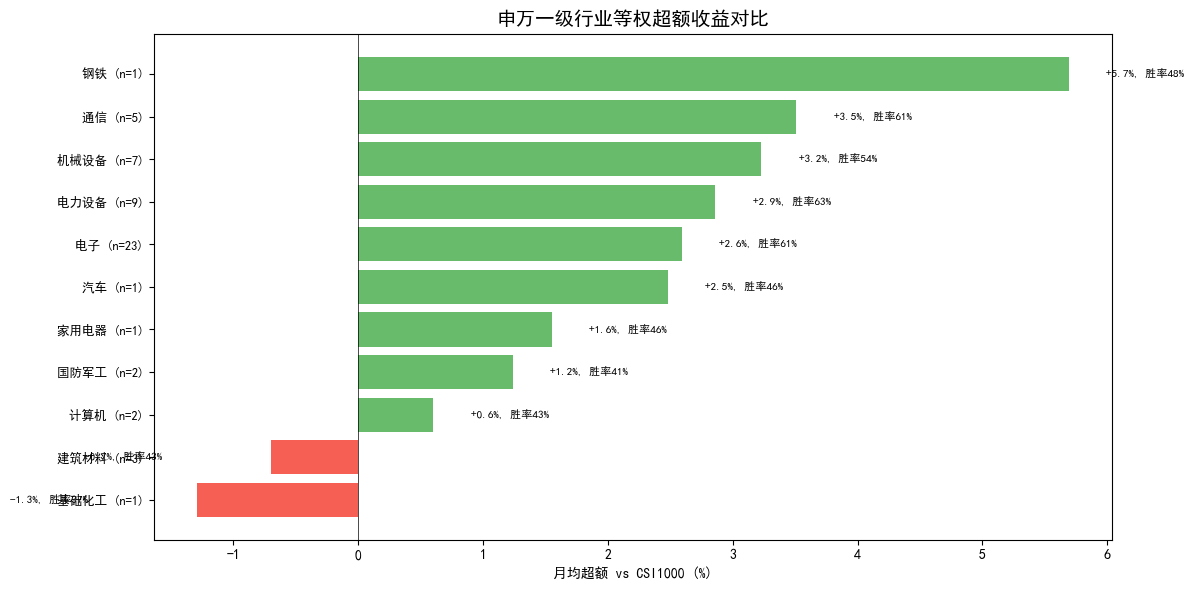

In [9]:
# Build SW industry portfolios
sw_returns = {}
for _, row in df55.iterrows():
    code = row['code']
    sw = row['sw']
    if code not in stock_monthly: continue
    if sw not in sw_returns: sw_returns[sw] = []
    sw_returns[sw].append(stock_monthly[code])

sw_port = {}
for sw, rets_list in sw_returns.items():
    if len(rets_list) < 1: continue
    all_dates_t = sorted(set(d for m in rets_list for d in m.index))
    monthly = []
    for dt in all_dates_t:
        vals = [m.loc[dt].iloc[0] for m in rets_list if dt in m.index and np.isfinite(m.loc[dt].iloc[0])]
        if len(vals) >= max(1, len(rets_list)*0.5):
            monthly.append({'date': dt, 'ret': np.mean(vals)})
    if monthly:
        sw_port[sw] = pd.DataFrame(monthly).set_index('date')

sw_summary = []
for sw, df_t in sw_port.items():
    common_t = df_t.index.intersection(csi1k_m.index)
    if len(common_t) < 3: continue
    ex = df_t.loc[common_t, 'ret'] - csi1k_m.loc[common_t].values
    sw_summary.append({
        '申万行业': sw,
        'n股票': len(sw_returns[sw]),
        'n月': len(common_t),
        '月均': round(ex.mean()*100, 2),
        '中位数': round(np.median(ex)*100, 2),
        '胜率': round((ex>0).mean()*100, 0),
        '累计': round(((1+pd.Series(ex.values, index=common_t)).cumprod()-1).iloc[-1]*100, 1)
    })

df_sw = pd.DataFrame(sw_summary).sort_values('月均', ascending=False)
print(df_sw.to_string(index=False))

# Chart: SW industry comparison
fig, ax = plt.subplots(figsize=(12, 6))
sw_plot = df_sw.sort_values('月均')
colors = ['#F44336' if x < 0 else '#4CAF50' for x in sw_plot['月均']]
ax.barh(range(len(sw_plot)), sw_plot['月均'], color=colors, alpha=0.85)
ax.set_yticks(range(len(sw_plot)))
ax.set_yticklabels([f'{s} (n={n})' for s,n in zip(sw_plot['申万行业'], sw_plot['n股票'])], fontsize=9)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('月均超额 vs CSI1000 (%)')
ax.set_title('申万一级行业等权超额收益对比', fontsize=14)
for i, (m, w) in enumerate(zip(sw_plot['月均'], sw_plot['胜率'])):
    ax.text(m + (0.3 if m >= 0 else -1.5), i, f'{m:+.1f}%, 胜率{w:.0f}%',
            va='center', fontsize=8)
plt.tight_layout()
plt.savefig('55stock_sw_excess.png', dpi=120, bbox_inches='tight')
plt.show()

## Part 5: 当前市场状态（描述统计，非预测）

以下为描述统计——当前月超额在全期中的位置，以及同标签月份的历史均值。不构成对未来收益的预测。

In [10]:
last = df_cond.iloc[-1]
last_dt = df_cond.index[-1]
recent3 = df_cond.iloc[-3:]

print(f'最新数据: {last_dt.date()}')
print(f'  组合月收益: {df_port.loc[last_dt,"ret"]*100:+.1f}%')
print(f'  CSI1000:    {csi1k_m.loc[last_dt]*100:+.1f}%')
print(f'  CSI300:     {csi300_m.loc[last_dt]*100:+.1f}%')
print(f'  超额vs CSI1000: {last["excess_1k"]*100:+.1f}%')
print(f'  超额vs CSI300:  {last["excess_300"]*100:+.1f}%')

cur_s = last['style']; cur_v = last['vol']
match = df_cond[(df_cond['style']==cur_s) & (df_cond['vol']==cur_v)]
print(f'\n  当前环境标签: {cur_s} x {cur_v}')
print(f'  (风格基于12月MA方向, 波动率基于中位数二分)')
print(f'  历史相同标签月份 (n={len(match)}):')
if len(match) > 0:
    print(f'    均值: {match["excess_1k"].mean()*100:+.1f}% (中位数 {match["excess_1k"].median()*100:+.1f}%)')
    print(f'    超额为正的比例: {(match["excess_1k"]>0).mean()*100:.0f}%')
    print(f'    | warning: 仅为描述统计，不构成对未来收益的预测')

print(f'\n  近3个月:')
for dt, row in recent3.iterrows():
    tag = '+' if row['excess_1k'] > 0 else '-'
    port_r = df_port.loc[dt,'ret']*100
    csi1k_r = csi1k_m.loc[dt]*100
    print(f'    {dt.date()}: 组合{port_r:+.1f}% vs CSI1000{csi1k_r:+.1f}% = 超额{row["excess_1k"]*100:+.1f}% {tag}')

# Percentile
cur_pct = (excess_1k < last['excess_1k']).mean() * 100
print(f'\n  全期{len(excess_1k)}个月中，当前月超额处于 {cur_pct:.0f}% 分位')

最新数据: 2026-05-31
  组合月收益: +14.4%
  CSI1000:    +3.7%
  CSI300:     +0.8%
  超额vs CSI1000: +10.7%
  超额vs CSI300:  +13.6%

  当前环境标签: 小盘偏强 x 高波
  (风格基于12月MA方向, 波动率基于中位数二分)
  历史相同标签月份 (n=24):
    均值: +0.9% (中位数 +0.6%)
    超额为正的比例: 54%
    | warning: 仅为描述统计，不构成对未来收益的预测

  近3个月:
    2026-03-31: 组合-7.1% vs CSI1000-11.0% = 超额+3.9% +
    2026-04-30: 组合+31.6% vs CSI1000+10.0% = 超额+21.6% +
    2026-05-31: 组合+14.4% vs CSI1000+3.7% = 超额+10.7% +

  全期76个月中，当前月超额处于 91% 分位


## Part 6: 研究局限 & 注意事项

### 数据层面
1. **时间跨度**: 全量数据覆盖2020-02~2026-05（76个月）。为确保足够覆盖率（≥30%阈值），有效面板从2022-02开始（53个月）。2020年仅27只有数据（15只2019前上市 + 后续IPO），2022年2月起49只可用，2023年后55只全覆盖。
2. **组合构成**: 早期月份实际可用股票数较少（2020年仅27只），等权组合随时间扩容。设了30%最低覆盖率阈值（同Q3扩展C G4）。

### 行业标签
3. **CSRC→SW映射**: 21只不在CSI300/500成分中的股票，其申万行业来自CSRC分类的手工映射（非官方对照表），可能存在偏差。这21只的行业标签不应作为精确的统计分组依据。

### 超额收益
4. **极端月**: 等权组合超额收益分布右偏。全期均值高于中位数，通过IQR×1.5去极值后均值显著降低。少数高弹性月份贡献了大部分累计超额。
5. **基准选择**: 52个月同口径下，CSI1000累计+53%，CSI300累计+21%。vs CSI300的超额之所以大（累计605%），正是因为CSI300本身没涨（+21%）。vs CSI1000超额更小（512%）但基准涨幅也更大（+53%）。两个基准的市值层不对等：组合加权平均~2000亿，在CSI300中位数（1058亿）和CSI500（285亿）之间。

### 后视偏差
6. 这55只基于"未来两年业绩能见度"精选——组合构建时隐含了事后信息。历史超额收益可能部分来自selection bias，不可视为策略模拟结果。

### 条件分组统计
7. **风格分类**: 当前使用12月MA方向(同Q1 1D)，但Q1也指出这种方法有约6个月滞后。分组标签反映的是趋势方向而非即时拐点。
8. **样本量**: 风格×波动率分组每个格仅10-19个月样本，统计可靠性有限。标注为描述统计。
9. **非预测**: 条件分组统计和历史同类环境回测仅描述历史规律。没有做样本外验证，不构成对未来收益的预测。